In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load the dataset
DataSet = pd.read_csv(r"C:\Users\admin\Downloads\Untitled spreadsheet - Sheet1 (2).csv") 
#DataSet

In [3]:
DataSet.head()

,ID,Date,City,AQI,PM2.5,PM10,NO2,SO2,CO,O3,Air_Quality
0,1,01-01-2024,Mumbai,151,67,32,99,37,1.25,45,Moderate
1,2,02-01-2024,Kanpur,248,289,64,80,56,0.34,33,Poor
2,3,03-01-2024,Chennai,248,129,278,82,5,2.61,176,Poor
3,4,04-01-2024,Lucknow,227,224,132,62,77,1.40,11,Poor
4,5,05-01-2024,Mumbai,220,226,194,40,21,1.13,96,Poor


In [4]:
DataSet.tail()

,ID,Date,City,AQI,PM2.5,PM10,NO2,SO2,CO,O3,Air_Quality
1995,1996,19-06-2024,Mumbai,169,112,110,42,35,3.20,77,Moderate
1996,1997,20-06-2024,Chennai,299,260,201,79,48,1.70,174,Poor
1997,1998,21-06-2024,Bhopal,304,240,343,92,23,0.36,159,Very Poor
1998,1999,22-06-2024,Jaipur,242,89,295,77,28,4.47,121,Poor
1999,2000,23-06-2024,Mumbai,203,157,126,48,66,2.57,78,Poor


In [5]:
DataSet.describe()

,ID,AQI,PM2.5,PM10,NO2,SO2,CO,O3
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,222.294500,152.783500,211.038500,61.354500,41.616000,2.333285,96.277500
std,577.494589,56.838729,83.197708,111.127146,33.779155,23.011091,1.231204,49.978259
min,1.000000,75.000000,10.000000,20.000000,5.000000,2.000000,0.210000,10.000000
25%,500.750000,181.000000,78.000000,111.000000,31.000000,21.000000,1.270000,52.000000
50%,1000.500000,222.500000,153.000000,209.500000,61.000000,42.000000,2.310000,95.000000
75%,1500.250000,262.000000,225.000000,310.250000,91.000000,62.000000,3.380000,141.000000
max,2000.000000,394.000000,300.000000,400.000000,120.000000,80.000000,4.500000,180.000000


In [6]:
DataSet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           2000 non-null   int64  
 1   Date         2000 non-null   object 
 2   City         2000 non-null   object 
 3   AQI          2000 non-null   int64  
 4   PM2.5        2000 non-null   int64  
 5   PM10         2000 non-null   int64  
 6   NO2          2000 non-null   int64  
 7   SO2          2000 non-null   int64  
 8   CO           2000 non-null   float64
 9   O3           2000 non-null   int64  
 10  Air_Quality  2000 non-null   object 
dtypes: float64(1), int64(7), object(3)
memory usage: 172.0+ KB


In [8]:
DataSet

,ID,Date,City,AQI,PM2.5,PM10,NO2,SO2,CO,O3,Air_Quality
0,1,01-01-2024,Mumbai,151,67,32,99,37,1.25,45,Moderate
1,2,02-01-2024,Kanpur,248,289,64,80,56,0.34,33,Poor
2,3,03-01-2024,Chennai,248,129,278,82,5,2.61,176,Poor
3,4,04-01-2024,Lucknow,227,224,132,62,77,1.40,11,Poor
4,5,05-01-2024,Mumbai,220,226,194,40,21,1.13,96,Poor
...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,19-06-2024,Mumbai,169,112,110,42,35,3.20,77,Moderate
1996,1997,20-06-2024,Chennai,299,260,201,79,48,1.70,174,Poor
1997,1998,21-06-2024,Bhopal,304,240,343,92,23,0.36,159,Very Poor
1998,1999,22-06-2024,Jaipur,242,89,295,77,28,4.47,121,Poor



Air Quality Category Count
Air_Quality
Poor            1098
Moderate         703
Very Poor        183
Satisfactory      16
Name: count, dtype: int64


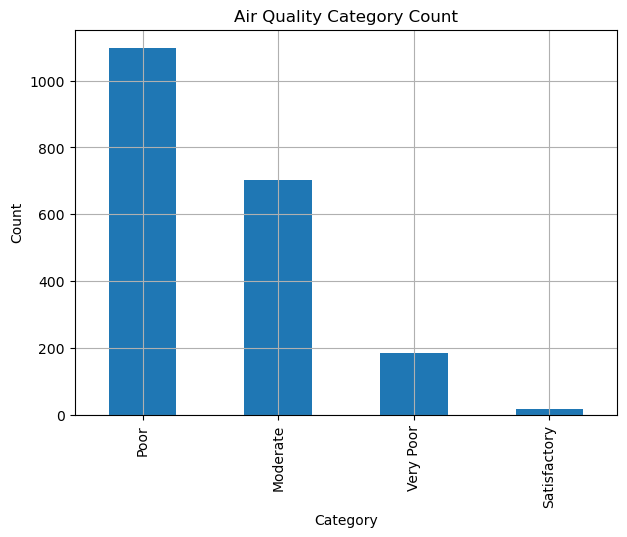

In [15]:
# ==========================================================
# 1. AQI CATEGORY COUNT
# ==========================================================

print("\nAir Quality Category Count")
print(df["Air_Quality"].value_counts())

plt.figure(figsize=(7,5))
df["Air_Quality"].value_counts().plot(kind="bar")
plt.title("Air Quality Category Count")
plt.xlabel("Category")
plt.ylabel("Count")
plt.grid(True)
plt.show()


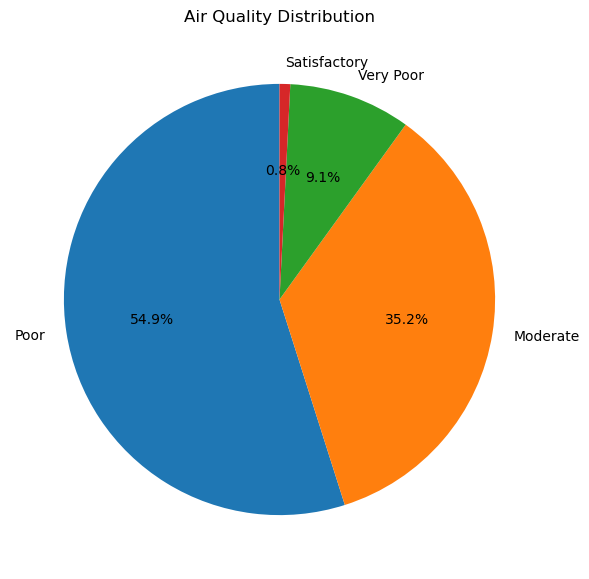

In [16]:
# ==========================================================
# 2. PIE CHART
# ==========================================================

plt.figure(figsize=(7,7))
df["Air_Quality"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Air Quality Distribution")
plt.ylabel("")
plt.show()



Average AQI by City
City
Kolkata      229.577982
Jaipur       228.398104
Lucknow      225.549763
Kanpur       224.740741
Hyderabad    222.459184
Patna        220.479798
Chennai      220.290000
Mumbai       218.671958
Bhopal       218.266055
Delhi        212.094118
Name: AQI, dtype: float64


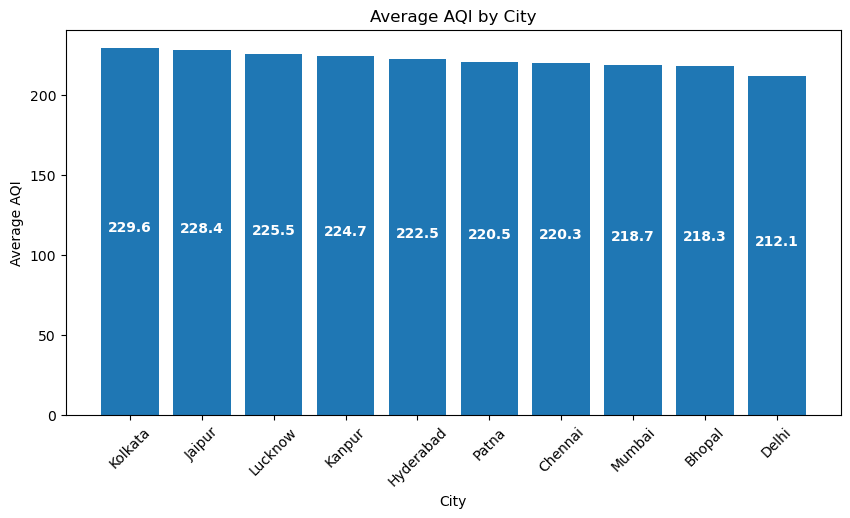

In [17]:
# ==========================================================
# 3. CITY WISE AVERAGE AQI
# ==========================================================

city_aqi = df.groupby("City")["AQI"].mean().sort_values(ascending=False)

print("\nAverage AQI by City")
print(city_aqi)

plt.figure(figsize=(10,5))
bars = plt.bar(city_aqi.index, city_aqi.values)

plt.title("Average AQI by City")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.xticks(rotation=45)

# Number in center of bar
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        y/2,
        f"{y:.1f}",
        ha="center",
        color="white",
        fontweight="bold"
    )

plt.show()

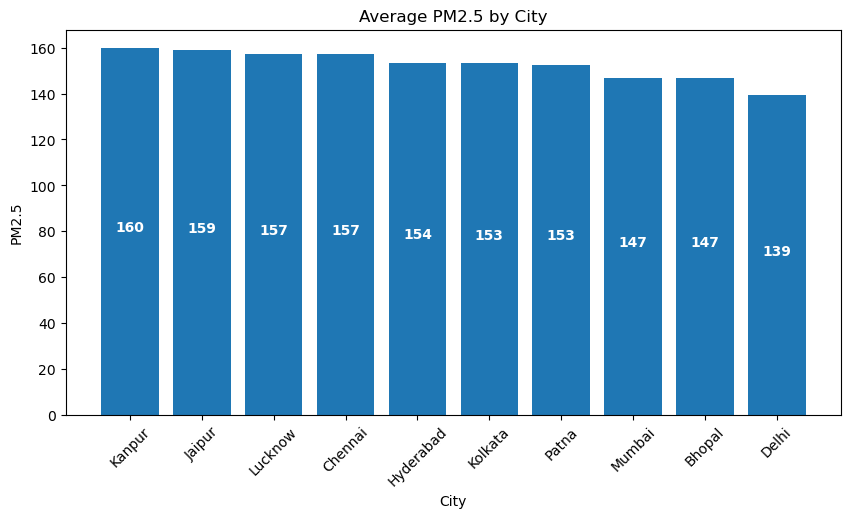

In [18]:
# ==========================================================
# 4. PM2.5 BY CITY
# ==========================================================

pm25 = df.groupby("City")["PM2.5"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
bars = plt.bar(pm25.index, pm25.values)

plt.title("Average PM2.5 by City")
plt.xlabel("City")
plt.ylabel("PM2.5")
plt.xticks(rotation=45)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        y/2,
        f"{y:.0f}",
        ha="center",
        color="white",
        fontweight="bold"
    )

plt.show()


Top 10 Highest AQI Records
        ID        Date     City  AQI  PM2.5  PM10  NO2  SO2    CO   O3  \
1279  1280  03-07-2024   Jaipur  394    299   385  119   70  3.83   69   
1105  1106  11-01-2024   Mumbai  378    296   334   93   69  3.84  151   
1674  1675  02-08-2024   Jaipur  374    284   372  105   22  4.35  121   
228    229  16-08-2024   Jaipur  372    239   368  117   74  2.96  169   
345    346  11-12-2024    Patna  370    267   380  103   41  3.17  173   
875    876  25-05-2024  Chennai  368    287   370  107   27  3.91   89   
1831  1832  07-01-2024    Delhi  362    289   377  119   16  2.71   77   
1767  1768  03-11-2024  Chennai  362    275   359  114   78  2.28   79   
575    576  29-07-2024  Lucknow  358    258   284  116   49  3.73  141   
628    629  20-09-2024  Lucknow  358    207   373  113   63  3.64  176   

     Air_Quality  
1279   Very Poor  
1105   Very Poor  
1674   Very Poor  
228    Very Poor  
345    Very Poor  
875    Very Poor  
1831   Very Poor  
1767 

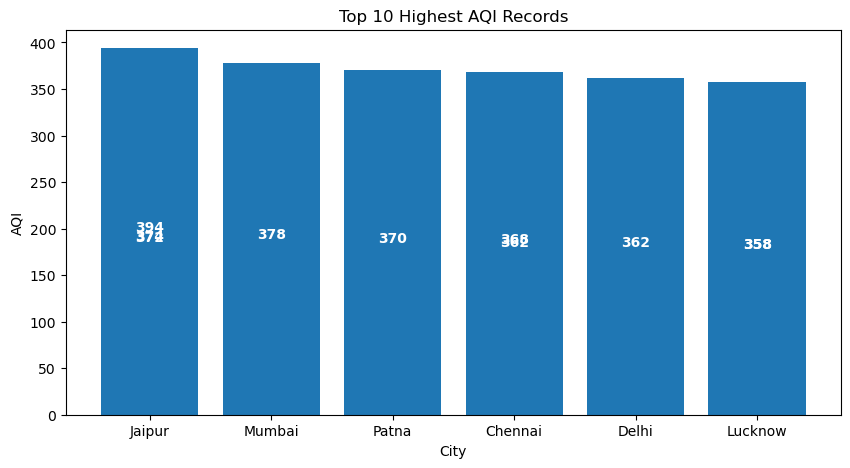

In [21]:
# ==========================================================
# 5. TOP 10 HIGHEST AQI RECORDS
# ==========================================================

top10 = df.sort_values("AQI", ascending=False).head(10)

print("\nTop 10 Highest AQI Records")
print(top10)

plt.figure(figsize=(10,5))
bars = plt.bar(top10["City"], top10["AQI"])

plt.title("Top 10 Highest AQI Records")
plt.xlabel("City")
plt.ylabel("AQI")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        y/2,
        int(y),
        ha="center",
        color="white",
        fontweight="bold"
    )

plt.show()


In [22]:

# ==========================================================
# FINAL REPORT
# ==========================================================

print("\nFINAL ANALYSIS REPORT")
print("="*40)
print("Total Records :", len(df))
print("Total Cities  :", df["City"].nunique())
print("Highest AQI   :", df["AQI"].max())
print("Lowest AQI    :", df["AQI"].min())
print("Average AQI   :", round(df["AQI"].mean(),2))

print("\nCity with Highest Average AQI :")
print(city_aqi.idxmax(), round(city_aqi.max(),2))

print("\nCity with Lowest Average AQI :")
print(city_aqi.idxmin(), round(city_aqi.min(),2))

print("\nAir Quality Category Summary")
print(df["Air_Quality"].value_counts())

print("\nProject Completed Successfully.")


FINAL ANALYSIS REPORT
Total Records : 2000
Total Cities  : 10
Highest AQI   : 394
Lowest AQI    : 75
Average AQI   : 222.29

City with Highest Average AQI :
Kolkata 229.58

City with Lowest Average AQI :
Delhi 212.09

Air Quality Category Summary
Air_Quality
Poor            1098
Moderate         703
Very Poor        183
Satisfactory      16
Name: count, dtype: int64

Project Completed Successfully.
